In [16]:
import os
import pandas as pd
import shutil

base_dir = r"C:\Users\muham\Downloads\DL PROJECT"
image_dir = os.path.join(base_dir, "images")
csv_path = os.path.join(base_dir, "HAM10000_metadata.csv")

# Read CSV
df = pd.read_csv(csv_path)

# Classes
classes = ['akiec','bcc','bkl','df','mel','nv','vasc']

# Create folders
for cls in classes:
    os.makedirs(os.path.join(base_dir, "dataset", cls), exist_ok=True)

# Copy images into class folders
for _, row in df.iterrows():
    img_name = row['image_id'] + ".jpg"
    label = row['dx']

    src = os.path.join(image_dir, img_name)
    dst = os.path.join(base_dir, "dataset", label, img_name)

    if os.path.exists(src):
        shutil.copy(src, dst)

print("✅ Dataset organized successfully!")

✅ Dataset organized successfully!


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [18]:
data_dir =r"C:\Users\muham\Downloads\DL PROJECT\dataset"

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(160,160),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(160,160),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 8015 images belonging to 7 classes.
Found 2000 images belonging to 7 classes.


In [32]:
lesion_names = {
    'akiec': 'Actinic Keratoses (pre-cancerous lesion)',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevus (mole)',
    'vasc': 'Vascular Lesion'
}

In [33]:
for cls in train_data.class_indices.keys():
    print(f"{cls} → {lesion_names[cls]}")

akiec → Actinic Keratoses (pre-cancerous lesion)
bcc → Basal Cell Carcinoma
bkl → Benign Keratosis
df → Dermatofibroma
mel → Melanoma
nv → Melanocytic Nevus (mole)
vasc → Vascular Lesion


In [20]:
labels = train_data.classes
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=labels)

class_weights = dict(enumerate(class_weights))

In [21]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(160,160,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.3354 - loss: 1.8010 - val_accuracy: 0.5975 - val_loss: 1.2601
Epoch 2/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 398s 3s/step - accuracy: 0.4520 - loss: 1.4731 - val_accuracy: 0.5735 - val_loss: 1.2448
Epoch 3/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.4784 - loss: 1.3876 - val_accuracy: 0.5105 - val_loss: 1.2930


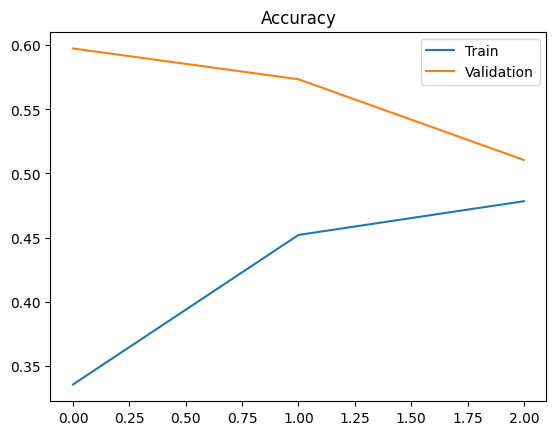

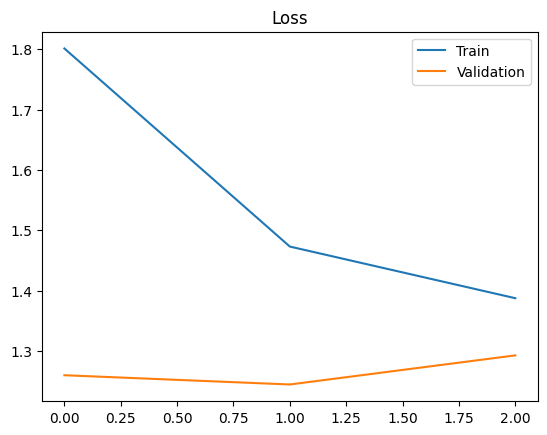

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

# 📉 Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


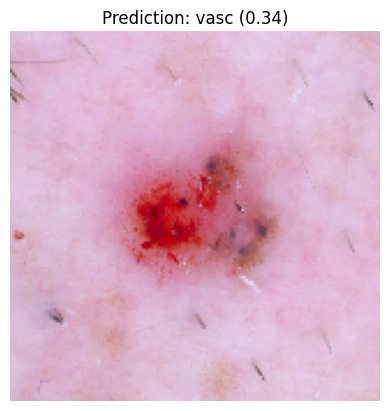

In [27]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

classes = list(train_data.class_indices.keys())

def predict_and_show(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(160,160))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    pred = model.predict(img_array)
    idx = np.argmax(pred)

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {classes[idx]} ({np.max(pred):.2f})")
    plt.show()
predict_and_show(r"C:\Users\muham\Downloads\DL PROJECT\dataset\bcc\ISIC_0024799.jpg")    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


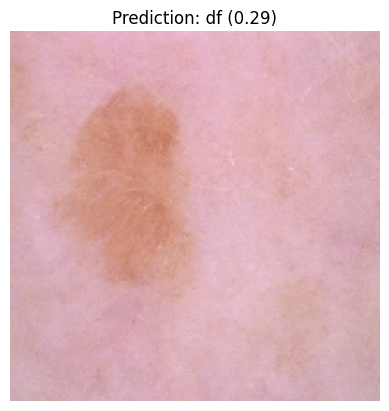

In [28]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

classes = list(train_data.class_indices.keys())

def predict_and_show(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(160,160))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    pred = model.predict(img_array)
    idx = np.argmax(pred)

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {classes[idx]} ({np.max(pred):.2f})")
    plt.show()
predict_and_show(r"C:\Users\muham\Downloads\DL PROJECT\dataset\bkl\ISIC_0025330.jpg")    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


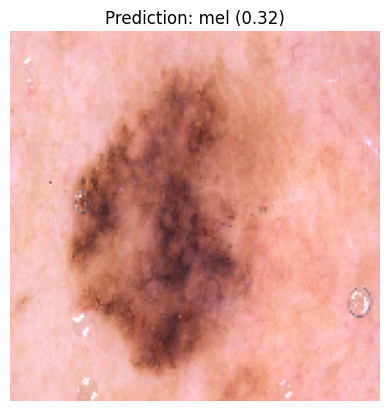

In [29]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

classes = list(train_data.class_indices.keys())

def predict_and_show(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(160,160))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    pred = model.predict(img_array)
    idx = np.argmax(pred)

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {classes[idx]} ({np.max(pred):.2f})")
    plt.show()
predict_and_show(r"C:\Users\muham\Downloads\DL PROJECT\dataset\mel\ISIC_0026089.jpg")    